## Name: plot_filter.ipynb

Author: Robby M. Frost

Advanced Radar Research Center, University of Oklahoma

Created: 12 November 2024

Purpose: Plot lidar PPIs using a low-pass filter

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import gzip
import os
from functions import *
import matplotlib.pyplot as plt
from matplotlib import rc
import pyart
from matplotlib.ticker import MultipleLocator
import zstandard as zstd
import io

Read in lidar file

In [34]:
# lidar file to read in
des_file = "20241029234838_CAPPI_177.nc.zst"
# date/time info of lidar scans
des_year = des_file[:4]
des_mon = des_file[4:6]
des_day = des_file[6:8]
des_hour = des_file[8:10]
des_min = des_file[10:12]
des_sec = des_file[12:14]
# lidar system info
des_sys = "ARRC" # ARRC, WG100-L0AD00003JP, or WG100-L0AD00004JP
lidar_loc = "ARRC Mobile" # Hampton, VA or ARRC
# directory = f"/data/arrcwx/robbyfrost/lidar_obs/{des_sys}/{des_year}/{des_mon}/{des_day}/"
directory = f"/data/arrcwx/MetroWeather/{des_sys}/{des_year}/{des_mon}/{des_year}{des_mon}{des_day}/"
# directory for saving figues
figdir = f"/home/robbyfrost/Analysis/TurbTor_Lidar/figures/{des_sys}/{des_year}/{des_mon}/{des_day}/"
os.makedirs(figdir, exist_ok=True)

# scan strategy info
des_elev = 5.
# snr threshold for masking out data
snr_cut = -10.
# start and end azimuths for averaging
az_start, az_end = 293.925, 358.99
# cutoff wavenumber for low-pass filter
cutoff = 1/5.

# full path to lidar file
file_path = directory + des_file
# read in compressed lidar file
with open(file_path, 'rb') as compressed_file:
    decompressor = zstd.ZstdDecompressor()
    # Decompress into memory
    decompressed_data = decompressor.decompress(compressed_file.read())
    # Create a file-like object from bytes
    file_like_obj = io.BytesIO(decompressed_data)
    # create xarray dataset
    ds = xr.open_dataset(file_like_obj, engine='h5netcdf')

# only include desired elevation
ds = ds.where(ds.elevation == des_elev, drop=True)
# filter out low snr on desired variables
good_snr = 10 * np.log10(ds.snr-1)
ds['dpl'] = ds.dpl.where(good_snr > snr_cut)
snr_mask = good_snr.values > snr_cut
snr_mask = snr_mask[:,0,:]

Set arrays of lidar data

In [35]:
# account for range offset
range_offset = 1425 # meters
start_point = np.argmin(abs(ds.ranges[:,0].data-range_offset))+1
# scan dimensions
az = ds.azimuth.data# * -1 + 90
r = ds.ranges[start_point:,0].data - range_offset
el = ds.elevation.data
# radial velocity
vr = ds.dpl[:,0,start_point:].data * -1
vr = vr
# calculate vertical vorticity
vort_z = ( (vr[1:,:] - vr[:-1,:]) / (np.deg2rad(az[1:]) - np.deg2rad(az[:-1]))[:,np.newaxis] ) * (1 / r)
# other observations
pwr = ds.pwr[:,0,start_point:].data * 100
snr = 10 * np.log10(ds.snr[:,0,start_point:].data - 1)
sw = ds.wth[:,0,start_point:].data
noise_level = ds.noise_level[:,0,start_point:].data
# power_spectra = ds.power_spectra[:,0,start_point:].data
doppler_velocity = ds.doppler_velocity.data
# lidar information
ob_method = ds.attrs['observation_method']
serial_number = ds.attrs['serial_number']
lat = ds.latitude.data
lon = ds.longitude.data
altitude = ds.altitude.data
# scan setting information
rpm_azimuth = ds.rpm_azimuth[start_point:].data
# scan time information
record_start_time = ds.start_time.data
start_time = ds.attrs['start_time'][11:19]
start_date = ds.attrs['start_time'][:10]
end_time = ds.attrs['end_time'][11:19]
end_date = ds.attrs['end_time'][:10]

# mask out low snr data
snr_mask = snr > snr_cut
vr = np.where(snr > snr_cut, vr, np.nan)
vr_smoothed = xr.DataArray(vr, dims=("az","r"), coords={'az': az, 'r': r}).rolling(az=3,r=3).mean().values

Apply low-pass filter to desired array

In [36]:
vr_filt = low_pass_filter(vr, az, r, cutoff, snr_mask)
az_filt = vr_filt.az.values
r_filt = vr_filt.r.values
vr_filt = vr_filt.values

Plotting set up

In [37]:
# Set the font weight for plot titles
# plt.rcParams['axes.titleweight'] = 'bold'
# Set the font weight for x-axis and y-axis labels
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'

# Other plotting setup
rc('font', family='sans-serif')
rc('font', weight='normal', size=15)
rc('figure', facecolor='white')

Plot radial velocity

/tmp/ipykernel_1288726/1248954721.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm1 = ax[0].pcolormesh(XX.T/1e3, YY.T/1e3, vr,
/tmp/ipykernel_1288726/1248954721.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm2 = ax[1].pcolormesh(XX.T/1e3, YY.T/1e3, vr_filt,


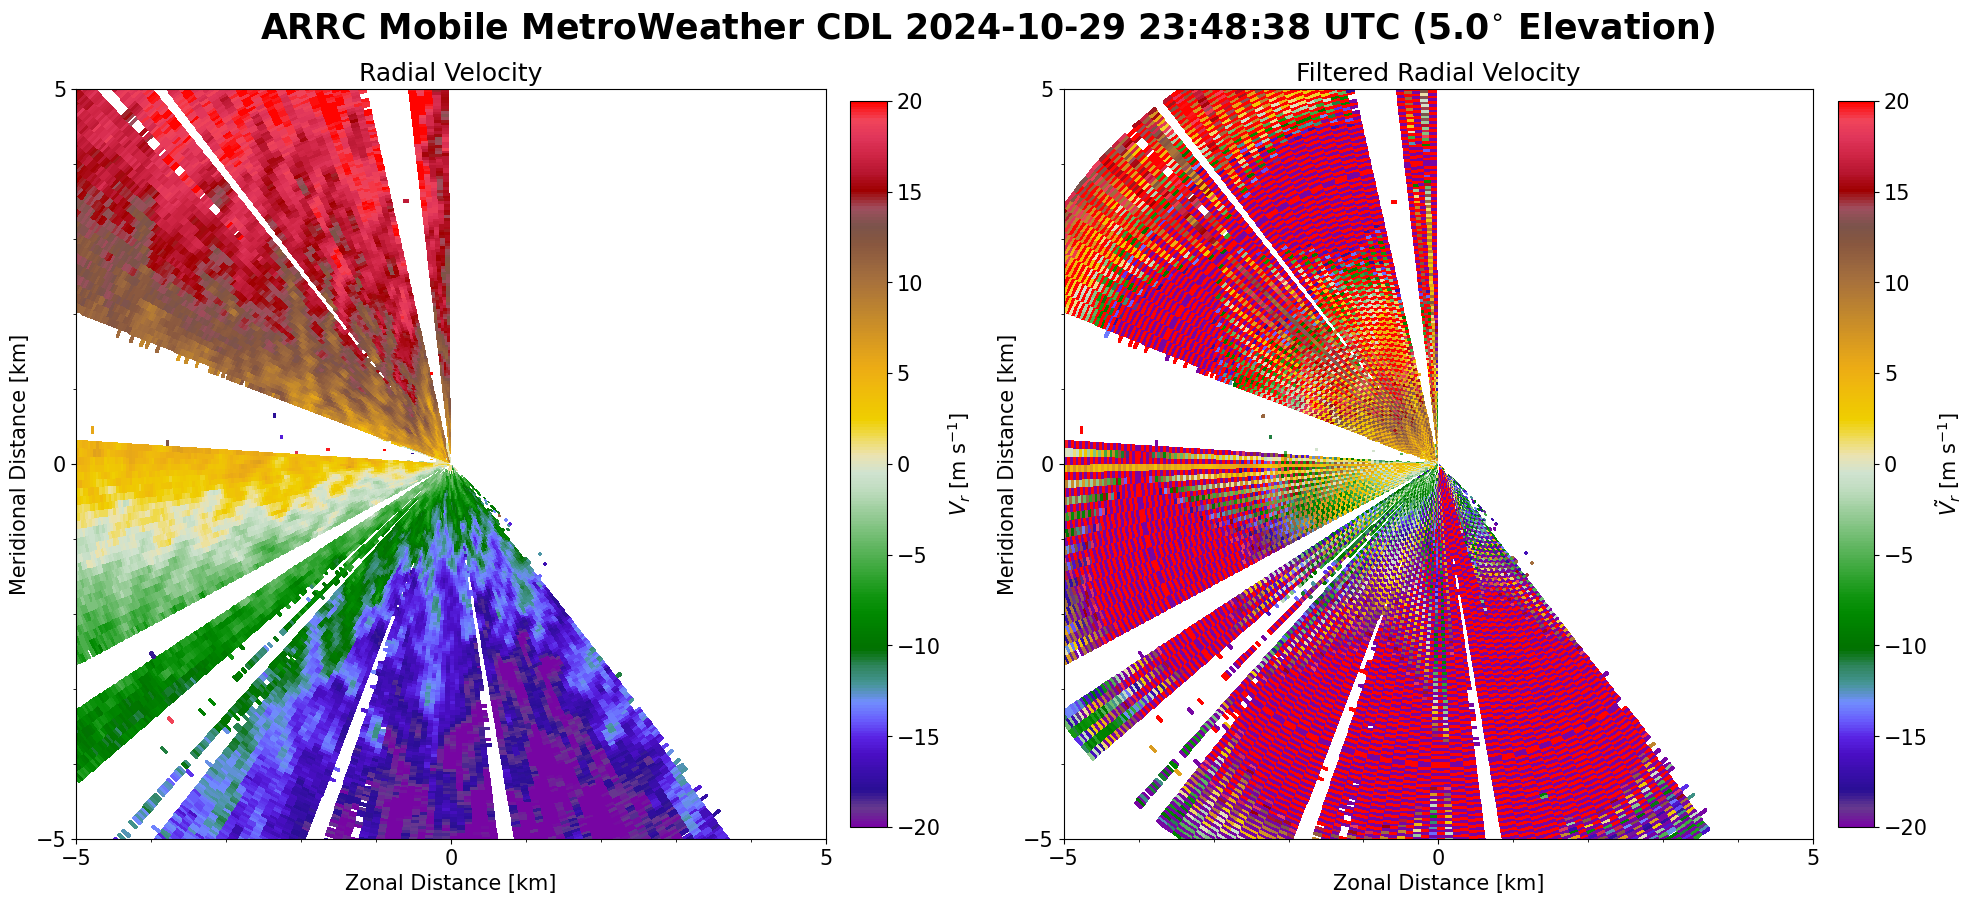

In [38]:
rmax = 5 # km

fig, ax = plt.subplots(figsize=(20,10), ncols=2)

vmin, vmax = -20, 20
XX, YY = dis_angle_to_2Dxy(r,north0_to_arctheta(az))
pcm1 = ax[0].pcolormesh(XX.T/1e3, YY.T/1e3, vr,
                        vmin=vmin, vmax=vmax,
                        cmap="pyart_Carbone42")
ax[0].set_title("Radial Velocity")
cbar1 = fig.colorbar(pcm1, ax=ax[0], aspect=20, pad=0.03, fraction=0.06, shrink=0.81)
cbar1.set_label("$V_r$ [m s$^{-1}$]")
cbar1.set_ticks(np.arange(vmin, vmax+0.001, 5))

vmin, vmax = -20, 20
XX, YY = dis_angle_to_2Dxy(r_filt,north0_to_arctheta(az_filt))
pcm2 = ax[1].pcolormesh(XX.T/1e3, YY.T/1e3, vr_filt,
                        vmin=vmin, vmax=vmax,
                        cmap="pyart_Carbone42")
ax[1].set_title("Filtered Radial Velocity")
cbar2 = fig.colorbar(pcm2, ax=ax[1], aspect=20, pad=0.03, fraction=0.06, shrink=0.81)
cbar2.set_label("$\\tilde{V_{r}}$ [m s$^{-1}$]")
cbar2.set_ticks(np.arange(vmin, vmax+0.0001, 5))

for iax in ax:
    iax.set_aspect('equal')
    iax.set_xlim(-rmax,rmax)
    iax.xaxis.set_major_locator(MultipleLocator(5))
    iax.xaxis.set_minor_locator(MultipleLocator(1))
    iax.set_xlabel("Zonal Distance [km]")
    iax.set_ylim(-rmax,rmax)
    iax.yaxis.set_major_locator(MultipleLocator(5))
    iax.yaxis.set_minor_locator(MultipleLocator(1))
    iax.set_ylabel("Meridional Distance [km]")

plt.suptitle(f"{lidar_loc} MetroWeather CDL {start_date} {start_time} UTC ({round(el[0],1)}$^{{\\circ}}$ Elevation)", 
             fontweight="bold", fontsize=25, y=0.925)

fig.tight_layout()

Compare raw and filtered vertical vorticity

In [39]:
vort_z_filt = ( (vr_filt[1:,:] - vr_filt[:-1,:]) / (np.deg2rad(az_filt[1:]) - np.deg2rad(az_filt[:-1]))[:,np.newaxis] ) * (1 / r_filt)
vort_z_smooth = ( (vr_smoothed[1:,:] - vr_smoothed[:-1,:]) / (np.deg2rad(az[1:]) - np.deg2rad(az[:-1]))[:,np.newaxis] ) * (1 / r)

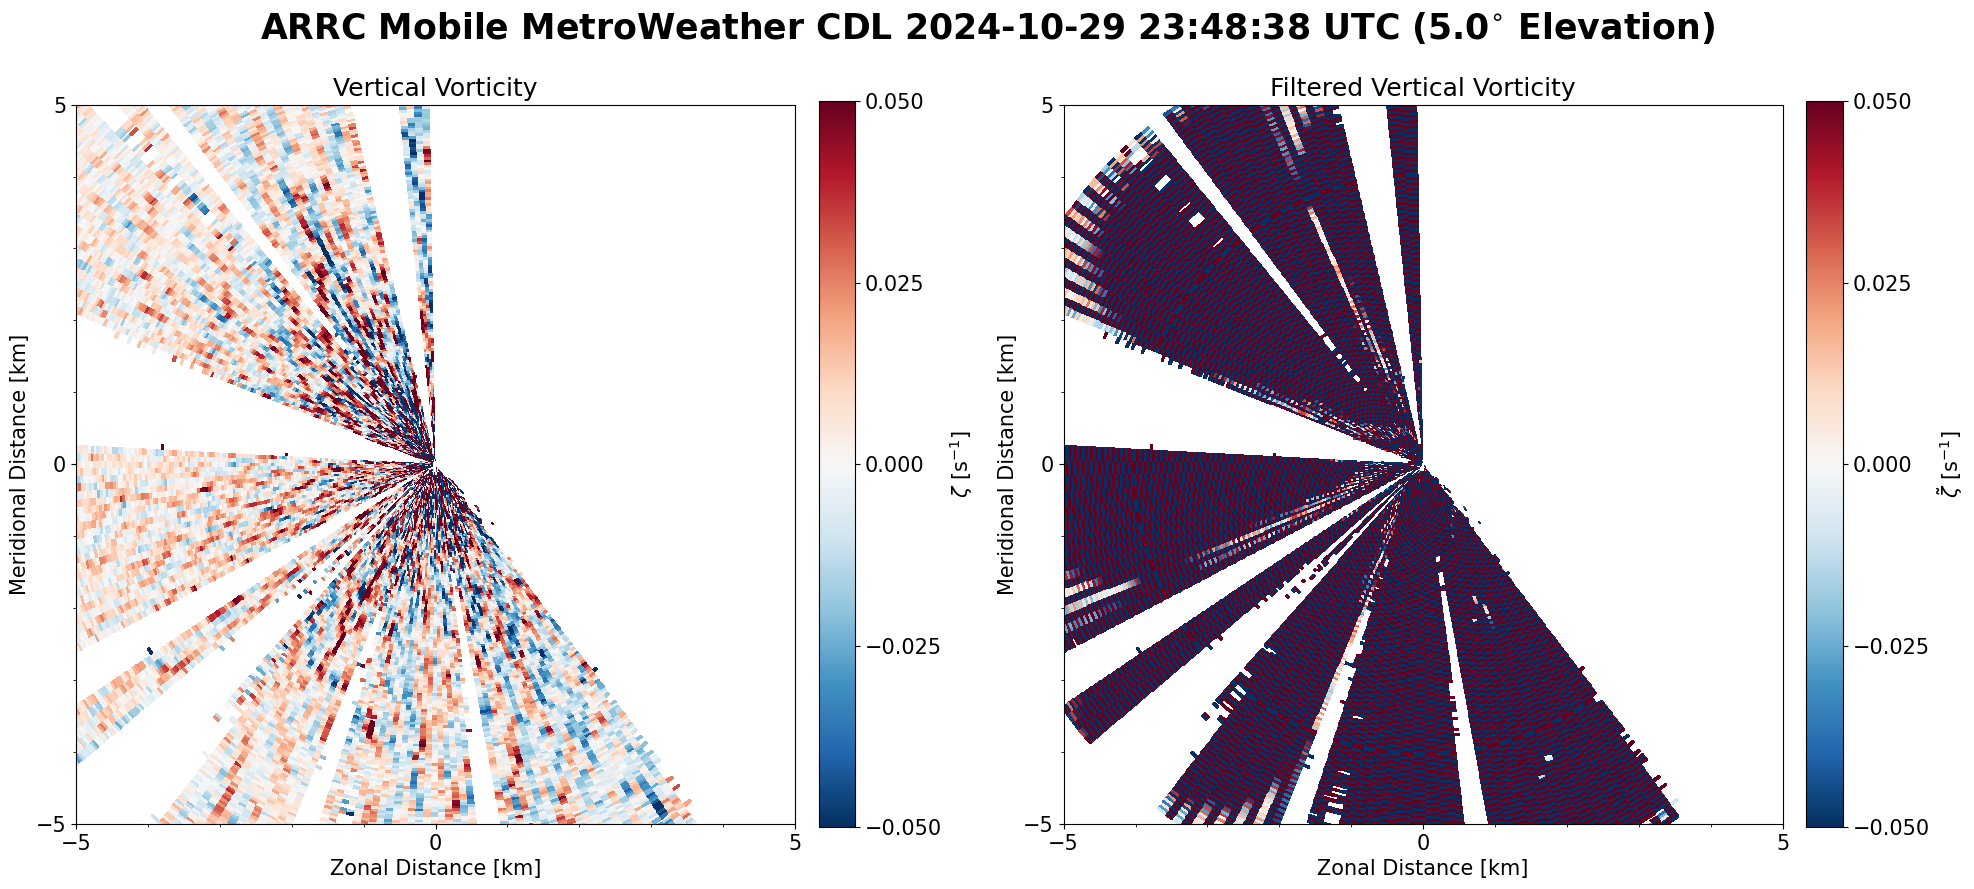

In [40]:
rmax = 5 # km

fig, ax = plt.subplots(figsize=(20,10), ncols=2)

vmin, vmax = -0.05, 0.05
XX, YY = dis_angle_to_2Dxy(r,north0_to_arctheta(az))
pcm1 = ax[0].pcolormesh(XX.T/1e3, YY.T/1e3, vort_z[:,:-1],
                        vmin=vmin, vmax=vmax,
                        cmap="RdBu_r")
ax[0].set_title("Vertical Vorticity")
cbar1 = fig.colorbar(pcm1, ax=ax[0], aspect=20, pad=0.03, fraction=0.06, shrink=0.81)
cbar1.set_label("$\\zeta$ [s$^{-1}$]")
cbar1.set_ticks(np.arange(vmin, vmax+0.001, 0.025))

vmin, vmax = -0.05, 0.05
XX, YY = dis_angle_to_2Dxy(r_filt,north0_to_arctheta(az_filt))
pcm2 = ax[1].pcolormesh(XX.T/1e3, YY.T/1e3, vort_z_filt[:,:-1],
                        vmin=vmin, vmax=vmax,
                        cmap="RdBu_r")
ax[1].set_title("Filtered Vertical Vorticity")
cbar2 = fig.colorbar(pcm2, ax=ax[1], aspect=20, pad=0.03, fraction=0.06, shrink=0.81)
cbar2.set_label("$\\tilde{\\zeta}$ [s$^{-1}$]")
cbar2.set_ticks(np.arange(vmin, vmax+0.0001, 0.025))

for iax in ax:
    iax.set_aspect('equal')
    iax.set_xlim(-rmax,rmax)
    iax.xaxis.set_major_locator(MultipleLocator(5))
    iax.xaxis.set_minor_locator(MultipleLocator(1))
    iax.set_xlabel("Zonal Distance [km]")
    iax.set_ylim(-rmax,rmax)
    iax.yaxis.set_major_locator(MultipleLocator(5))
    iax.yaxis.set_minor_locator(MultipleLocator(1))
    iax.set_ylabel("Meridional Distance [km]")

plt.suptitle(f"{lidar_loc} MetroWeather CDL {start_date} {start_time} UTC ({round(el[0],1)}$^{{\\circ}}$ Elevation)", 
             fontweight="bold", fontsize=25, y=0.925)

fig.tight_layout()

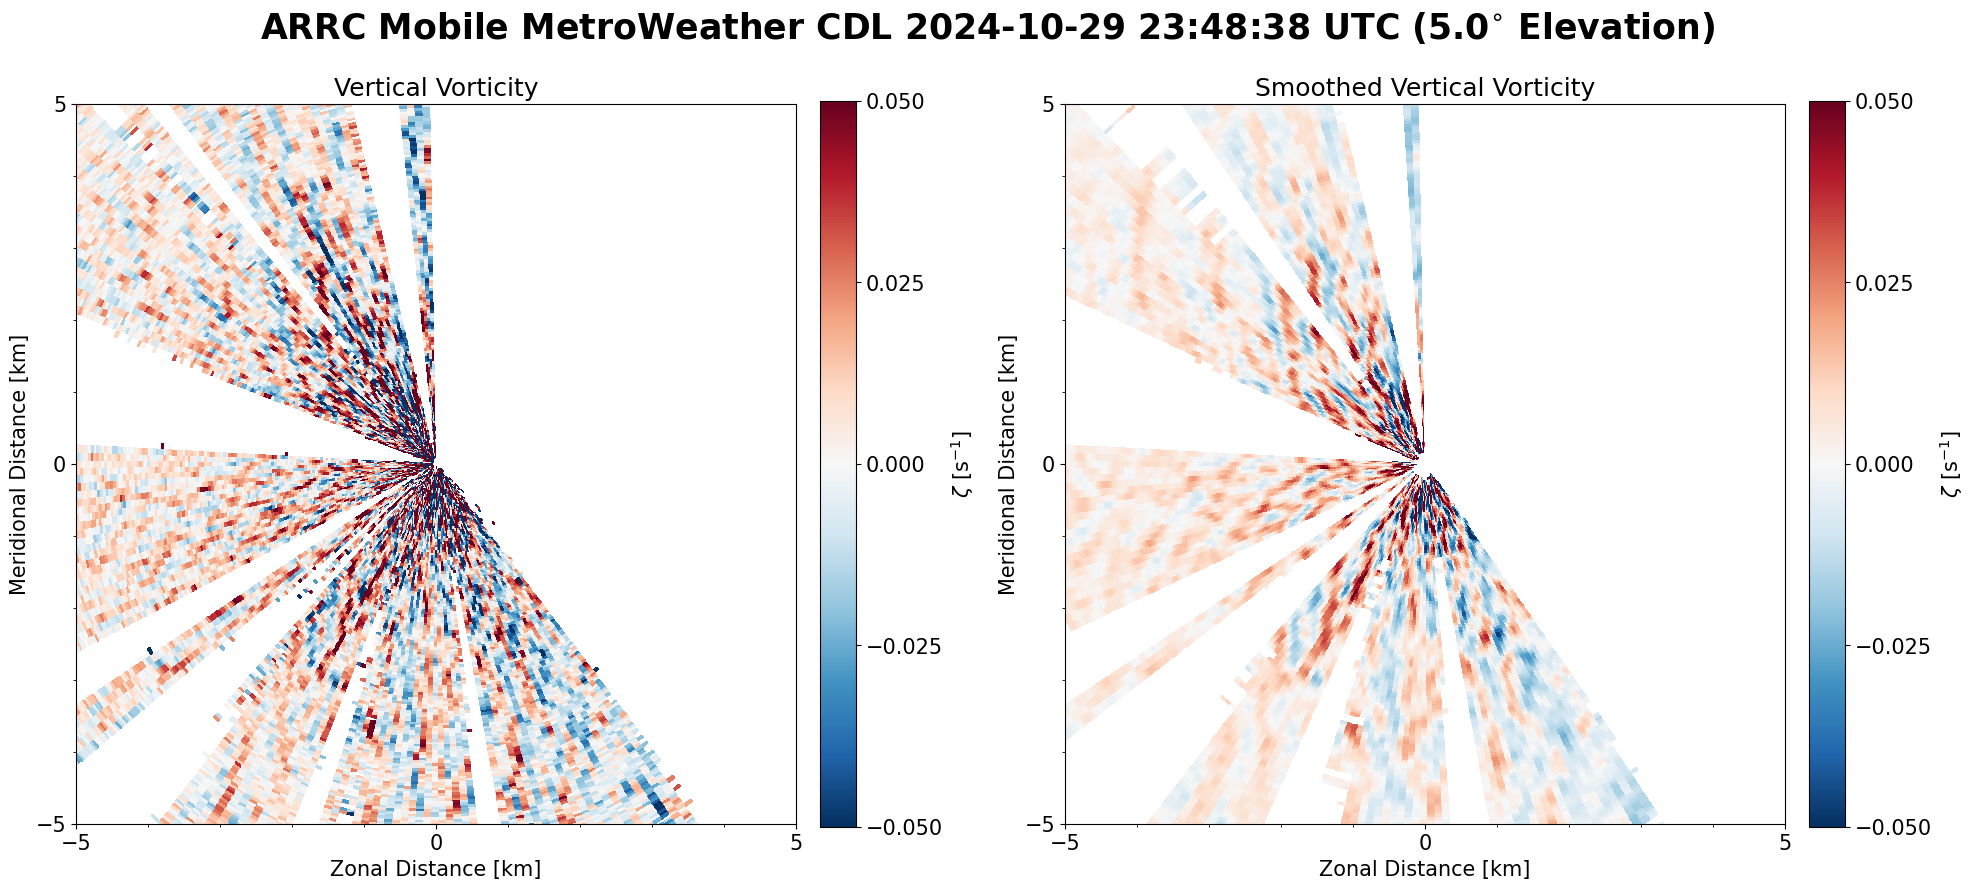

In [46]:
rmax = 5 # km

fig, ax = plt.subplots(figsize=(20,10), ncols=2)

vmin, vmax = -0.05, 0.05
XX, YY = dis_angle_to_2Dxy(r,north0_to_arctheta(az))
pcm1 = ax[0].pcolormesh(XX.T/1e3, YY.T/1e3, vort_z[:,:-1],
                        vmin=vmin, vmax=vmax,
                        cmap="RdBu_r")
ax[0].set_title("Vertical Vorticity")
cbar1 = fig.colorbar(pcm1, ax=ax[0], aspect=20, pad=0.03, fraction=0.06, shrink=0.81)
cbar1.set_label("$\\zeta$ [s$^{-1}$]")
cbar1.set_ticks(np.arange(vmin, vmax+0.001, 0.025))

vmin, vmax = -0.05, 0.05
XX, YY = dis_angle_to_2Dxy(r,north0_to_arctheta(az))
pcm2 = ax[1].pcolormesh(XX.T/1e3, YY.T/1e3, vort_z_smooth[:,:-1],
                        vmin=vmin, vmax=vmax,
                        cmap="RdBu_r")
ax[1].set_title("Smoothed Vertical Vorticity")
cbar2 = fig.colorbar(pcm2, ax=ax[1], aspect=20, pad=0.03, fraction=0.06, shrink=0.81)
cbar2.set_label("${\\zeta}$ [s$^{-1}$]")
cbar2.set_ticks(np.arange(vmin, vmax+0.0001, 0.025))

for iax in ax:
    iax.set_aspect('equal')
    iax.set_xlim(-rmax,rmax)
    iax.xaxis.set_major_locator(MultipleLocator(5))
    iax.xaxis.set_minor_locator(MultipleLocator(1))
    iax.set_xlabel("Zonal Distance [km]")
    iax.set_ylim(-rmax,rmax)
    iax.yaxis.set_major_locator(MultipleLocator(5))
    iax.yaxis.set_minor_locator(MultipleLocator(1))
    iax.set_ylabel("Meridional Distance [km]")

plt.suptitle(f"{lidar_loc} MetroWeather CDL {start_date} {start_time} UTC ({round(el[0],1)}$^{{\\circ}}$ Elevation)", 
             fontweight="bold", fontsize=25, y=0.925)

fig.tight_layout()

In [45]:
vort_z.shape

(182, 312)

In [44]:
XX.shape

(162, 183)